In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

# Find project root safely
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

data_path = project_root / "data" / "processed.cleveland.data"

column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    data_path,
    names=column_names,
    na_values="?"
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Run Basic Dataset Checks

In [11]:
# Check number of rows and columns
df.shape

(303, 14)

In [12]:
# Check column names, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [13]:
# Basic statistics
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [14]:
# Check missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [15]:
# Check target values
df["target"].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [16]:
csv_path = project_root / "data" / "heart.csv"

df.to_csv(csv_path, index=False)

print("Dataset saved to:", csv_path)

Dataset saved to: d:\Projects\heart-disease-risk-prediction\data\heart.csv


# Step 5: Understand and Clean the Dataset

In this step, we will:

1. Check missing values
2. Check duplicate rows
3. Convert target into binary form
4. Save cleaned dataset

This project is using the ML concepts you studied, especially classification, skewed data, decision trees, and XGBoost.

#### 1. Check Missing Values

In [17]:
# Check missing values in each column
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

#### 2. Check Duplicate Rows

In [18]:
# Check duplicate rows
df.duplicated().sum()

0

In [19]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check shape after removing duplicates
df.shape

(303, 14)

#### 3. Handle Missing Values

In [20]:
# Remove rows with missing values
df = df.dropna()

# Check again
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [21]:
df.shape

(297, 14)

#### 4. Convert Target into Binary Classification

In [22]:
# Convert target into binary classification
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

# Check new target values
df["target"].value_counts()

target
0    160
1    137
Name: count, dtype: int64

#### 5. Check Data Types

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


In [24]:
int_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "slope", "ca", "thal", "target"
]

df[int_columns] = df[int_columns].astype(int)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int32  
 1   sex       297 non-null    int32  
 2   cp        297 non-null    int32  
 3   trestbps  297 non-null    int32  
 4   chol      297 non-null    int32  
 5   fbs       297 non-null    int32  
 6   restecg   297 non-null    int32  
 7   thalach   297 non-null    int32  
 8   exang     297 non-null    int32  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int32  
 11  ca        297 non-null    int32  
 12  thal      297 non-null    int32  
 13  target    297 non-null    int32  
dtypes: float64(1), int32(13)
memory usage: 19.7 KB


#### 6. Save the Cleaned Dataset

In [26]:
cleaned_path = project_root / "data" / "heart_cleaned.csv"

df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved to:", cleaned_path)

Cleaned dataset saved to: d:\Projects\heart-disease-risk-prediction\data\heart_cleaned.csv


# Step 6: Exploratory Data Analysis

#### Load Cleaned Dataset Again

In [27]:
# Step 6: Exploratory Data Analysis

cleaned_path = project_root / "data" / "heart_cleaned.csv"

df = pd.read_csv(cleaned_path)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


#### Check Dataset Shape After Cleaning and Target Distribution

In [28]:
df.shape

(297, 14)

In [29]:
target_counts = df["target"].value_counts()
print(target_counts)

target
0    160
1    137
Name: count, dtype: int64


#### Step 6.0: Add Chart Design Setup

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Create folder to save chart images for portfolio/README
figures_path = project_root / "reports" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

# Professional chart design
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#F8F9FA"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Color palette
green = "#2E8B57"
red = "#D64545"
blue = "#3A86FF"
orange = "#FF9F1C"
purple = "#8338EC"
gray = "#6C757D"

def save_chart(filename):
    plt.tight_layout()
    plt.savefig(figures_path / filename, dpi=300, bbox_inches="tight")
    plt.show()

#### Step 6.1: Target Distribution Chart

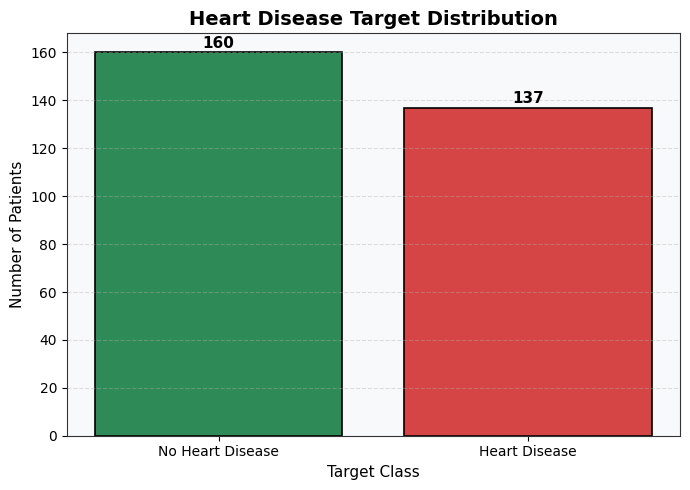

In [31]:
target_counts = df["target"].value_counts().reindex([0, 1])

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["No Heart Disease", "Heart Disease"],
    target_counts.values,
    color=[green, red],
    edgecolor="black",
    linewidth=1.2
)

plt.xlabel("Target Class")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Target Distribution")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        str(height),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
save_chart("target_distribution.png")

#### Step 6.2: Age Distribution

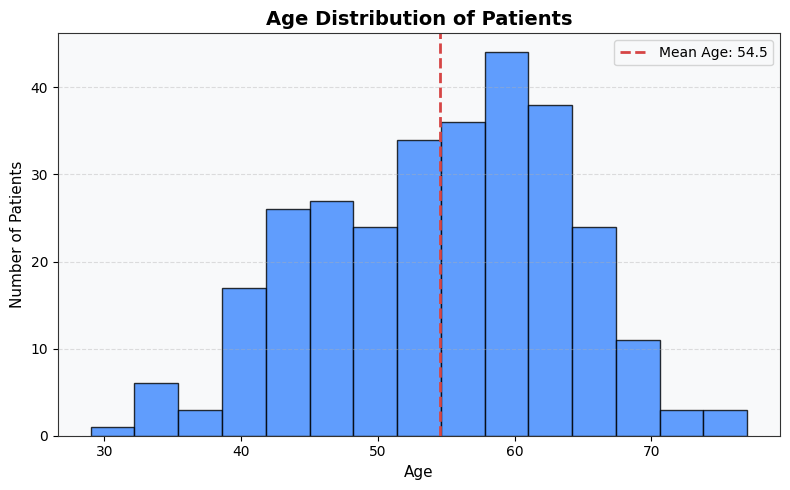

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["age"],
    bins=15,
    color=blue,
    edgecolor="black",
    alpha=0.8
)

mean_age = df["age"].mean()

plt.axvline(
    mean_age,
    color=red,
    linestyle="--",
    linewidth=2,
    label=f"Mean Age: {mean_age:.1f}"
)

plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of Patients")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

save_chart("age_distribution.png")

#### Step 6.3: Heart Disease by Sex

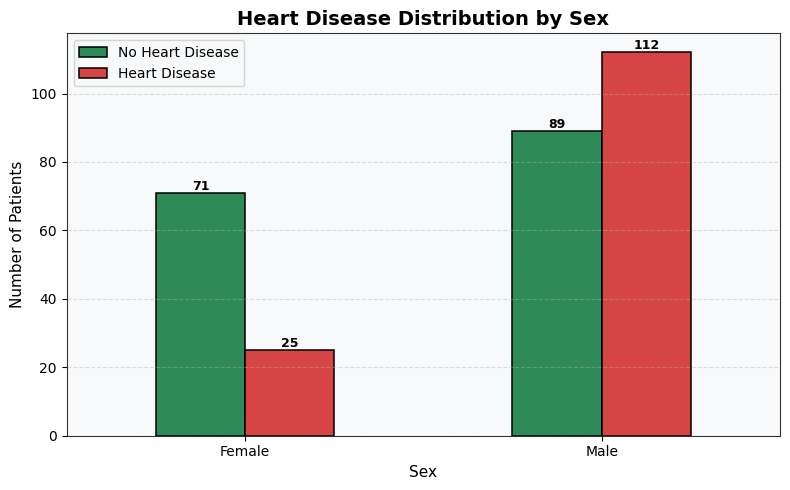

In [33]:
sex_target = pd.crosstab(df["sex"], df["target"])

ax = sex_target.plot(
    kind="bar",
    figsize=(8, 5),
    color=[green, red],
    edgecolor="black",
    linewidth=1.1
)

plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Distribution by Sex")
plt.xticks(ticks=[0, 1], labels=["Female", "Male"], rotation=0)
plt.legend(["No Heart Disease", "Heart Disease"])
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add labels above bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight="bold")

save_chart("heart_disease_by_sex.png")

#### Step 6.4: Chest Pain Type vs Heart Disease

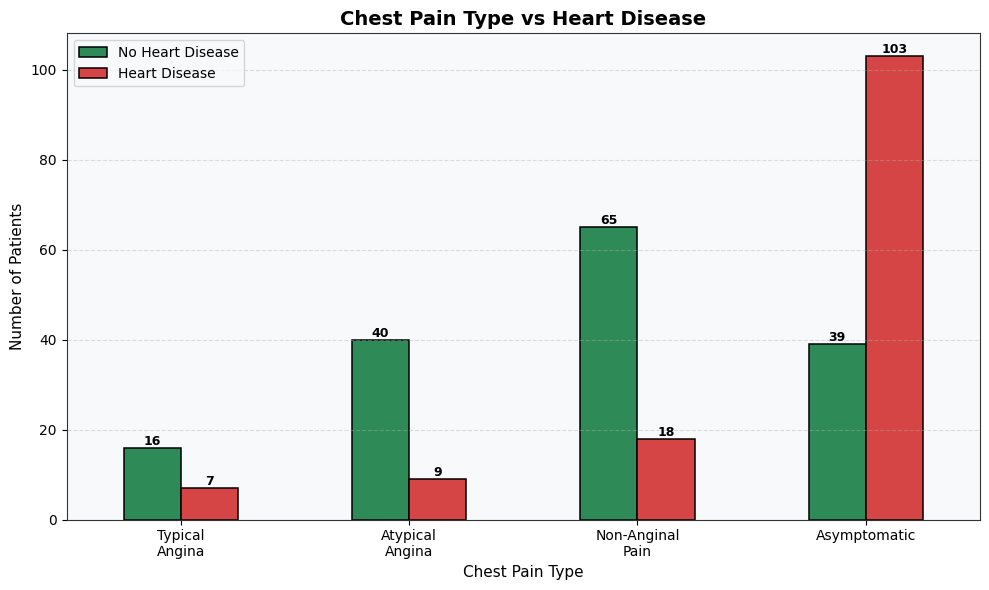

In [34]:
cp_target = pd.crosstab(df["cp"], df["target"])

ax = cp_target.plot(
    kind="bar",
    figsize=(10, 6),
    color=[green, red],
    edgecolor="black",
    linewidth=1.1
)

plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.title("Chest Pain Type vs Heart Disease")

# Replace numeric labels with meaningful names
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "Typical\nAngina",
        "Atypical\nAngina",
        "Non-Anginal\nPain",
        "Asymptomatic"
    ],
    rotation=0
)

plt.legend(["No Heart Disease", "Heart Disease"])
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight="bold")

save_chart("chest_pain_vs_heart_disease.png")

#### Step 6.5: Cholesterol Distribution

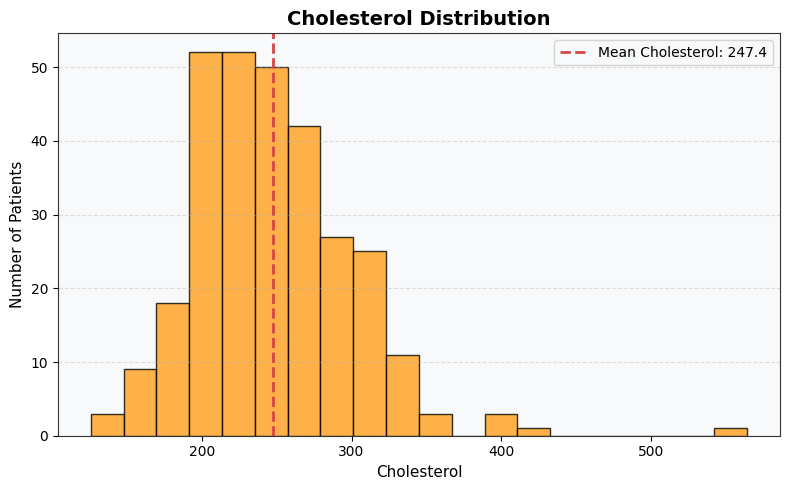

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["chol"],
    bins=20,
    color=orange,
    edgecolor="black",
    alpha=0.8
)

mean_chol = df["chol"].mean()

plt.axvline(
    mean_chol,
    color=red,
    linestyle="--",
    linewidth=2,
    label=f"Mean Cholesterol: {mean_chol:.1f}"
)

plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")
plt.title("Cholesterol Distribution")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

save_chart("cholesterol_distribution.png")

#### Step 6.6: Cholesterol by Heart Disease Status

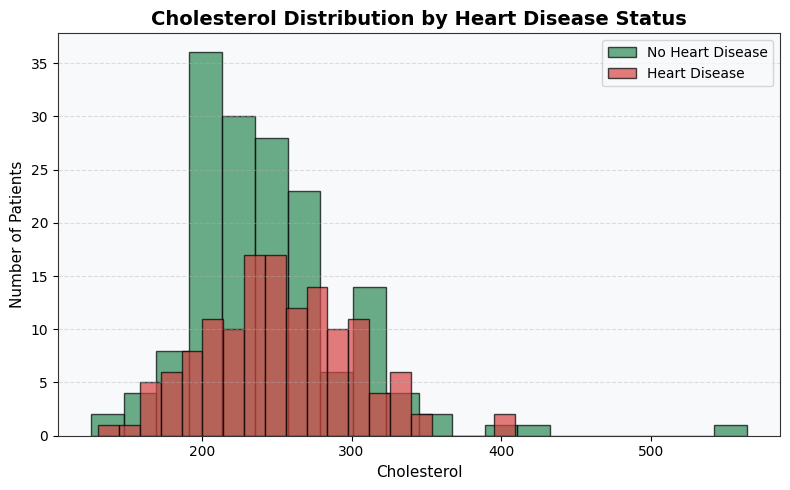

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["target"] == 0]["chol"],
    bins=20,
    alpha=0.7,
    label="No Heart Disease",
    color=green,
    edgecolor="black"
)

plt.hist(
    df[df["target"] == 1]["chol"],
    bins=20,
    alpha=0.7,
    label="Heart Disease",
    color=red,
    edgecolor="black"
)

plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")
plt.title("Cholesterol Distribution by Heart Disease Status")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

save_chart("cholesterol_by_target.png")

#### Step 6.7: Age vs Maximum Heart Rate

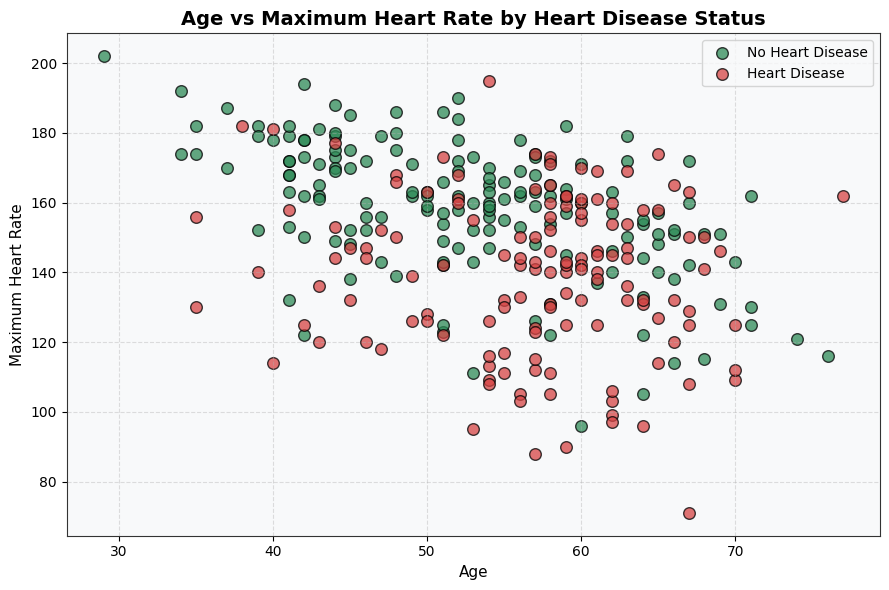

In [37]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df[df["target"] == 0]["age"],
    df[df["target"] == 0]["thalach"],
    color=green,
    label="No Heart Disease",
    alpha=0.75,
    edgecolor="black",
    s=70
)

plt.scatter(
    df[df["target"] == 1]["age"],
    df[df["target"] == 1]["thalach"],
    color=red,
    label="Heart Disease",
    alpha=0.75,
    edgecolor="black",
    s=70
)

plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.title("Age vs Maximum Heart Rate by Heart Disease Status")
plt.legend()
plt.grid(linestyle="--", alpha=0.4)

save_chart("age_vs_max_heart_rate.png")

#### Step 6.8: Correlation Heatmap

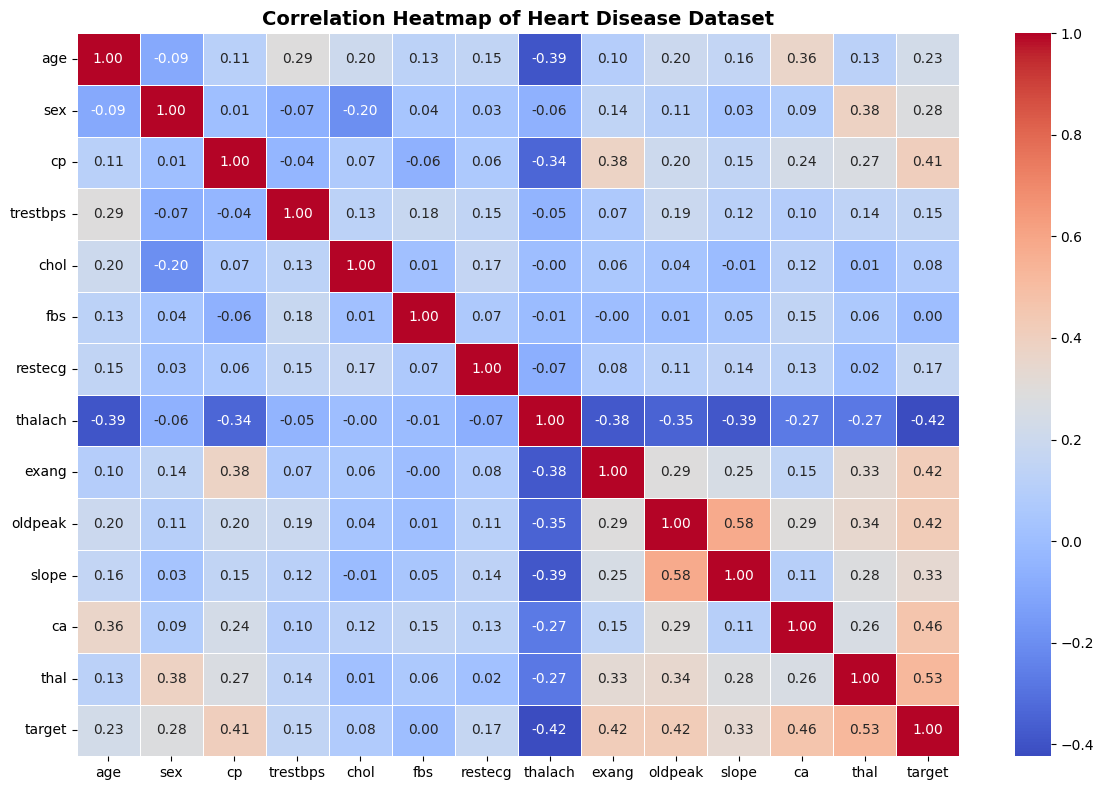

In [38]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    cbar=True
)

plt.title("Correlation Heatmap of Heart Disease Dataset")

save_chart("correlation_heatmap.png")

#### Step 6.9: Feature Correlation with Target

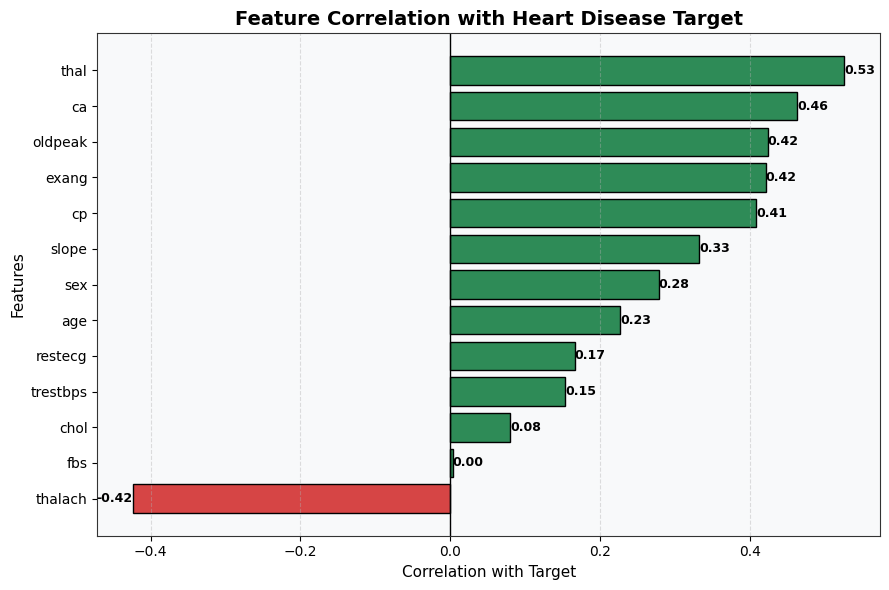

In [39]:
target_corr = df.corr()["target"].drop("target").sort_values()

plt.figure(figsize=(9, 6))

colors = [red if value < 0 else green for value in target_corr.values]

bars = plt.barh(
    target_corr.index,
    target_corr.values,
    color=colors,
    edgecolor="black"
)

plt.xlabel("Correlation with Target")
plt.ylabel("Features")
plt.title("Feature Correlation with Heart Disease Target")
plt.axvline(0, color="black", linewidth=1)
plt.grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        ha="left" if width > 0 else "right",
        fontsize=9,
        fontweight="bold"
    )

save_chart("feature_correlation_with_target.png")

#### Step 6.10: Chest Pain Type Pie Chart

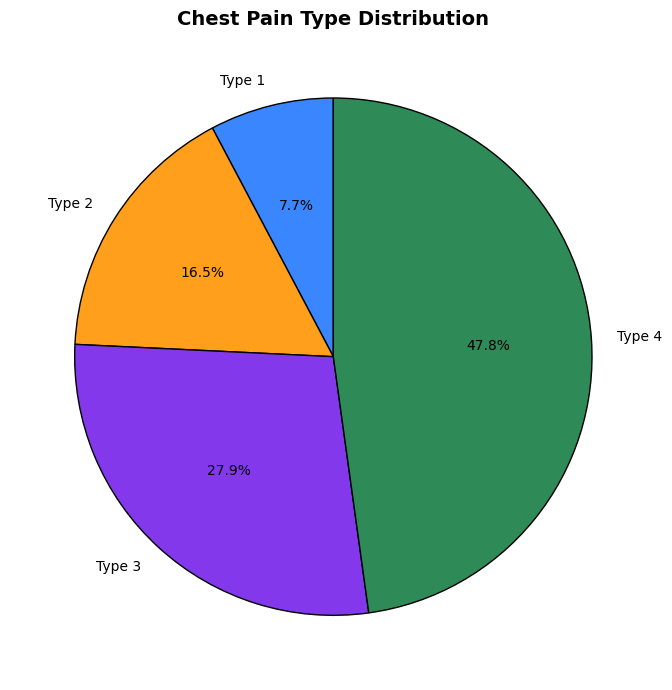

In [40]:
cp_counts = df["cp"].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    cp_counts.values,
    labels=[f"Type {i}" for i in cp_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=[blue, orange, purple, green],
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

plt.title("Chest Pain Type Distribution")

save_chart("chest_pain_type_distribution.png")

# Step 7: Split Data into Training and Testing Sets

#### Step 7.1: Prepare Features and Target

In [41]:
# Step 7: Split Data into Training and Testing Sets

# Separate input features and target variable
X = df.drop("target", axis=1)
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (297, 13)
Target vector shape: (297,)


#### Step 7.2: Check Target Balance Again

In [42]:

# Check target distribution before splitting
print(y.value_counts())

print("\nTarget distribution percentage:")
print(y.value_counts(normalize=True) * 100)

target
0    160
1    137
Name: count, dtype: int64

Target distribution percentage:
target
0    53.872054
1    46.127946
Name: proportion, dtype: float64


#### Step 7.3: Train-Test Split

In [43]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (237, 13)
X_test shape: (60, 13)
y_train shape: (237,)
y_test shape: (60,)


#### Step 7.4: Verify Class Balance After Splitting

In [44]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
target
0    54.008439
1    45.991561
Name: proportion, dtype: float64

Testing target distribution:
target
0    53.333333
1    46.666667
Name: proportion, dtype: float64


# Step 8: Train Baseline Model using Logistic Regression

#### Step 8.1: Import Model and Evaluation Metrics

In [45]:
# Step 8: Train Baseline Model using Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

#### Step 8.2: Create and Train Logistic Regression Model

In [46]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

#### Step 8.3: Make Predictions

In [47]:
y_pred_logistic = logistic_model.predict(X_test)

y_pred_logistic

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1], dtype=int64)

#### Step 8.4: Evaluate Logistic Regression

In [48]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1-score:", logistic_f1)

Logistic Regression Results
Accuracy: 0.8333333333333334
Precision: 0.8461538461538461
Recall: 0.7857142857142857
F1-score: 0.8148148148148148


#### Step 8.5: Classification Report

In [49]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



#### Step 8.6: Confusion Matrix

In [50]:
conf_matrix_logistic = confusion_matrix(y_test, y_pred_logistic)

conf_matrix_logistic

array([[28,  4],
       [ 6, 22]], dtype=int64)

# Step 9: Train Decision Tree Model using Entropy

#### Step 9.1: Import Decision Tree and Metrics

In [51]:
# Step 9: Train Decision Tree Model using Entropy

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

#### Step 9.2: Create Decision Tree Model

In [52]:
decision_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

#### Step 9.3: Train the Decision Tree Model

In [53]:
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

#### Step 9.4: Make Predictions

In [54]:
y_pred_tree = decision_tree_model.predict(X_test)

y_pred_tree

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1], dtype=int64)

#### Step 9.5: Evaluate Decision Tree Model

In [55]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1-score:", tree_f1)

Decision Tree Results
Accuracy: 0.7666666666666667
Precision: 0.85
Recall: 0.6071428571428571
F1-score: 0.7083333333333334


#### Step 9.6: Classification Report

In [56]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.72      0.91      0.81        32
           1       0.85      0.61      0.71        28

    accuracy                           0.77        60
   macro avg       0.79      0.76      0.76        60
weighted avg       0.78      0.77      0.76        60



#### Step 9.7: Confusion Matrix

In [57]:
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)

conf_matrix_tree

array([[29,  3],
       [11, 17]], dtype=int64)

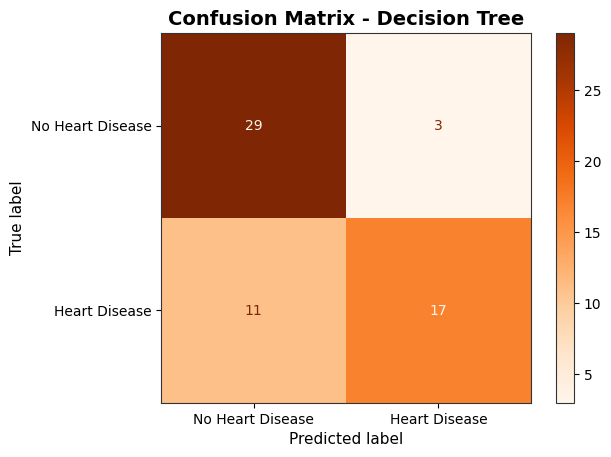

In [58]:
ConfusionMatrixDisplay.from_estimator(
    decision_tree_model,
    X_test,
    y_test,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap="Oranges"
)

plt.title("Confusion Matrix - Decision Tree")
plt.grid(False)
plt.show()

#### Step 9.8: Visualize the Decision Tree

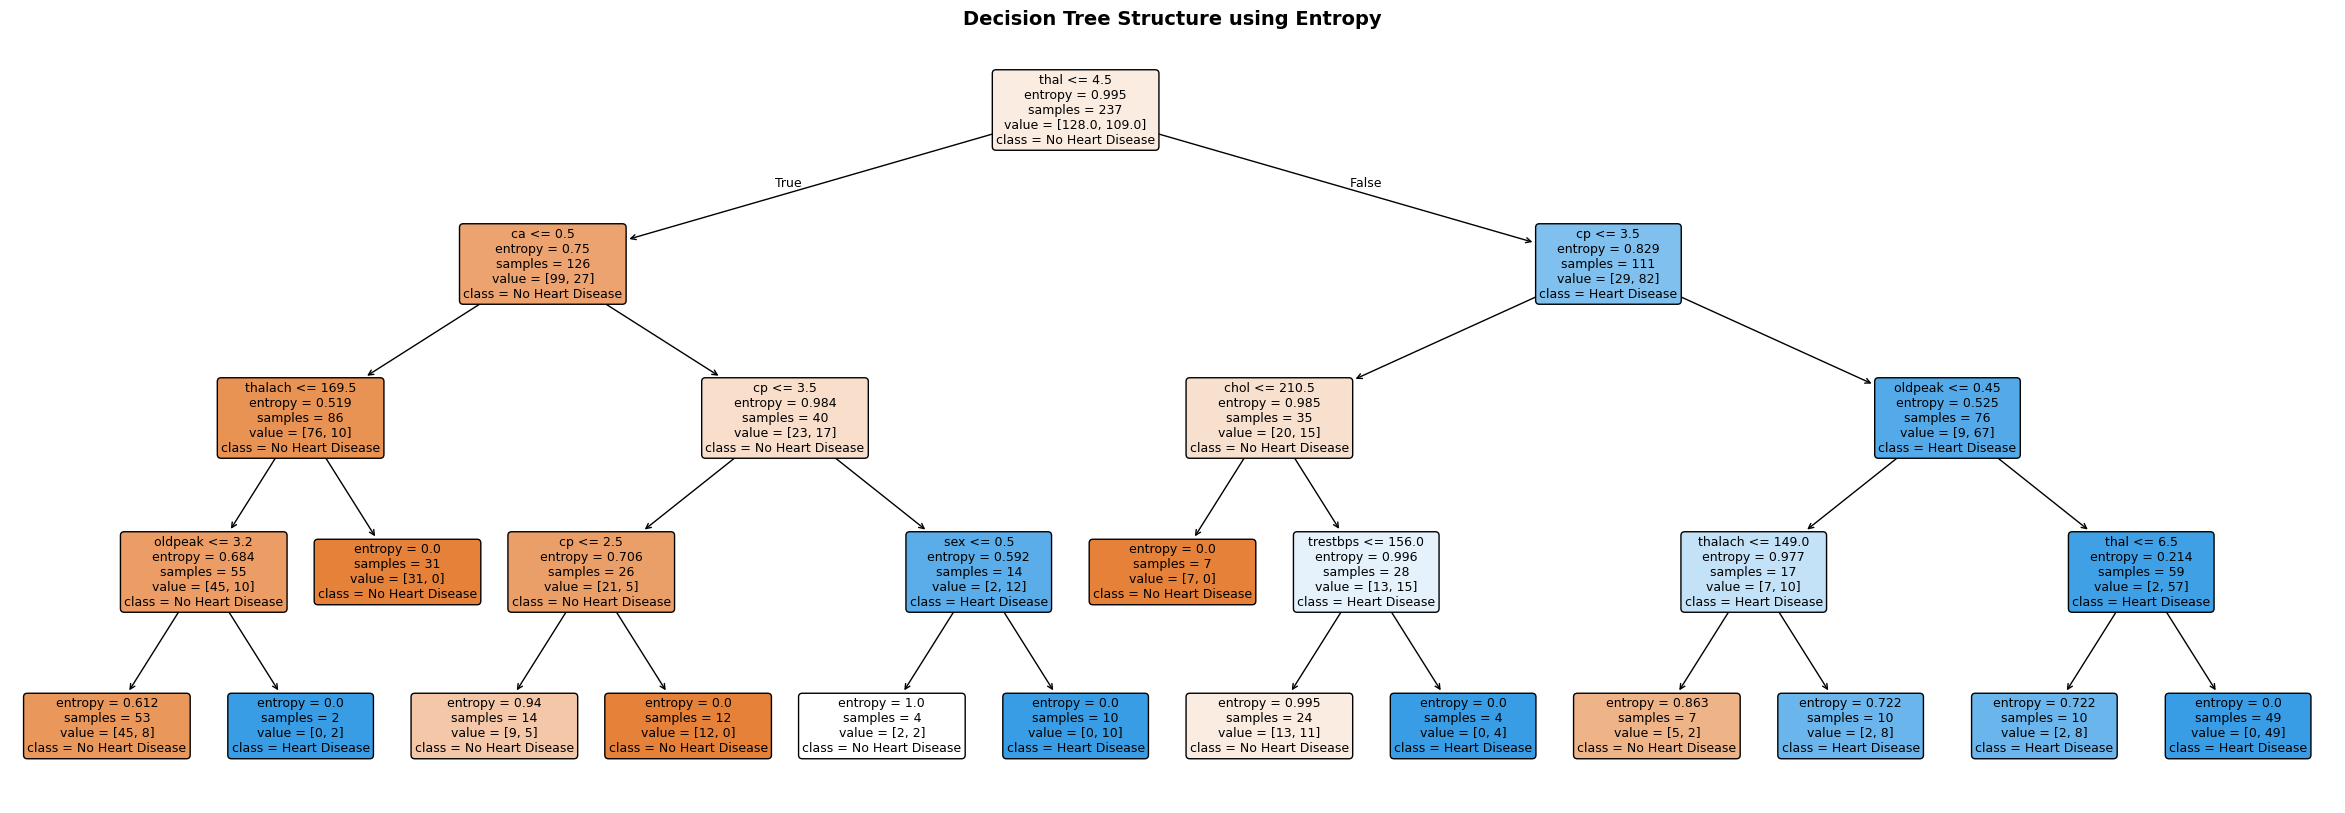

In [59]:
plt.figure(figsize=(30, 10))

plot_tree(
    decision_tree_model,
    feature_names=X.columns,
    class_names=["No Heart Disease", "Heart Disease"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Structure using Entropy")
plt.show()

#### Step 9.9: Feature Importance for Decision Tree

In [60]:
tree_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

tree_importance

,Feature,Importance
12,thal,0.386484
2,cp,0.250210
9,oldpeak,0.111630
11,ca,0.074006
7,thalach,0.072782
4,chol,0.046404
1,sex,0.030180
3,trestbps,0.028304
0,age,0.000000
5,fbs,0.000000


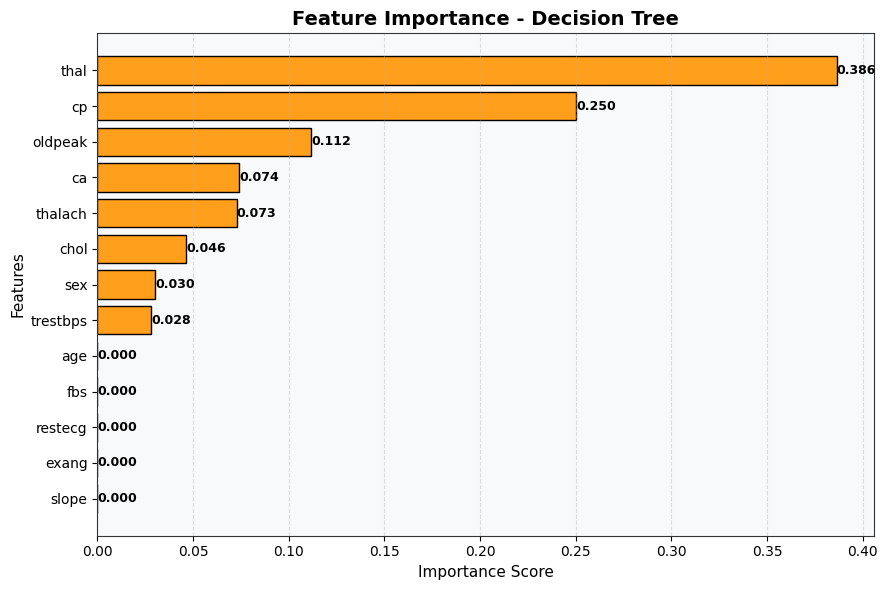

In [61]:
plt.figure(figsize=(9, 6))

bars = plt.barh(
    tree_importance["Feature"],
    tree_importance["Importance"],
    color="#FF9F1C",
    edgecolor="black"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

#### Step 9.10: Compare Logistic Regression and Decision Tree

In [62]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logistic_accuracy, tree_accuracy],
    "Precision": [logistic_precision, tree_precision],
    "Recall": [logistic_recall, tree_recall],
    "F1-score": [logistic_f1, tree_f1]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.833333,0.846154,0.785714,0.814815
1,Decision Tree,0.766667,0.850000,0.607143,0.708333


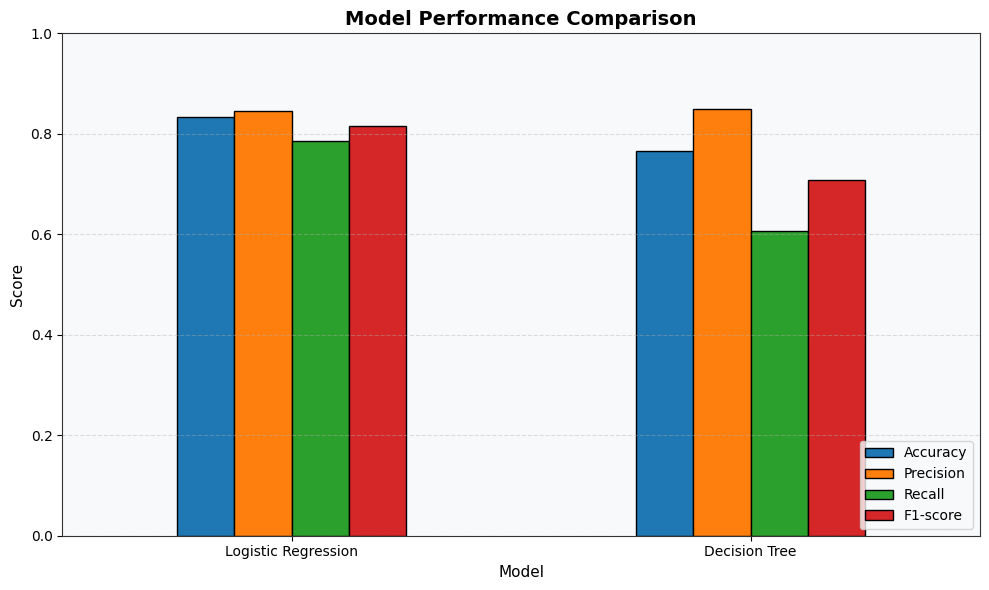

In [63]:
model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black"
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Step 10: Train XGBoost Model

1. Import XGBoost
2. Create XGBoost model
3. Train model
4. Make predictions
5. Evaluate model
6. Plot confusion matrix
7. Check feature importance
8. Compare Logistic Regression, Decision Tree, and XGBoost

#### Step 10.1: Import XGBoost and Metrics

In [64]:
# Step 10: Train XGBoost Model

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

#### Step 10.2: Create XGBoost Model

In [65]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

#### Step 10.3: Train XGBoost Model

In [66]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

#### Step 10.4: Make Predictions

In [67]:
y_pred_xgb = xgb_model.predict(X_test)

y_pred_xgb

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1])

#### Step 10.5: Evaluate XGBoost Model

In [68]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1-score:", xgb_f1)

XGBoost Results
Accuracy: 0.85
Precision: 0.88
Recall: 0.7857142857142857
F1-score: 0.8301886792452831


#### Step 10.6: Classification Report

In [69]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



#### Step 10.7: Confusion Matrix

In [70]:
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

conf_matrix_xgb

array([[29,  3],
       [ 6, 22]], dtype=int64)

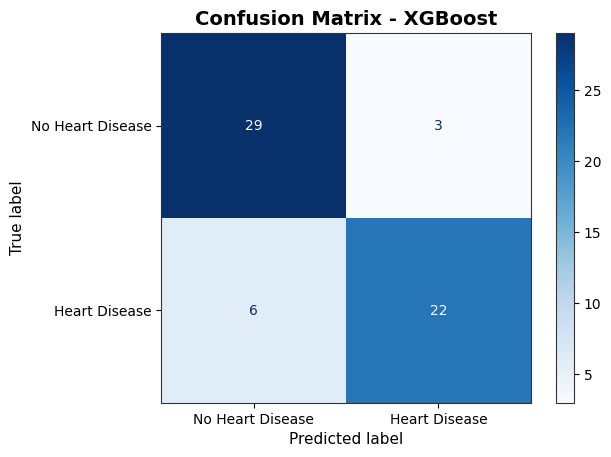

In [71]:
ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost")
plt.grid(False)
plt.show()

#### Step 10.8: XGBoost Feature Importance

In [73]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance

,Feature,Importance
12,thal,0.203998
2,cp,0.171518
11,ca,0.105589
10,slope,0.078319
9,oldpeak,0.067809
1,sex,0.056953
4,chol,0.051310
8,exang,0.051070
0,age,0.048635
7,thalach,0.046418


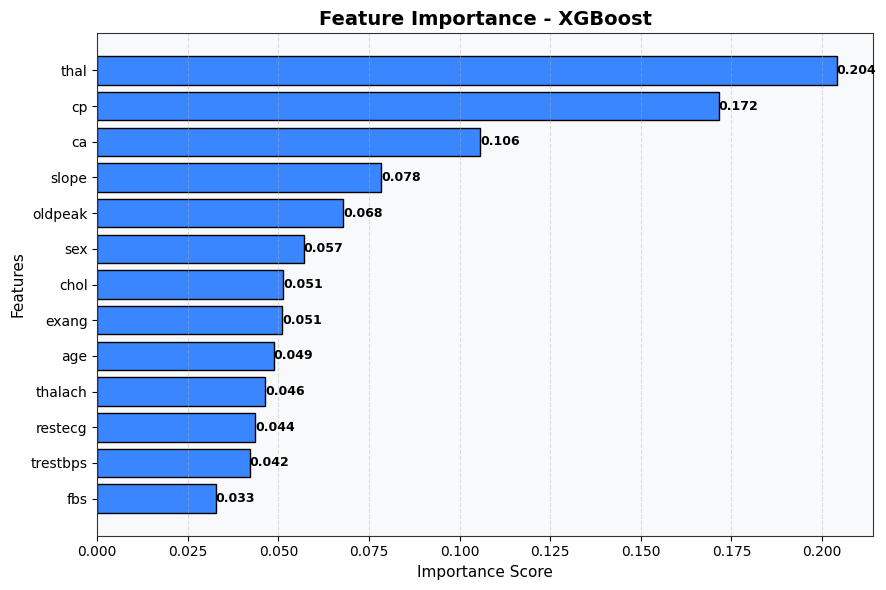

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

# Create reports/figures folder if it does not exist
figures_path = project_root / "reports" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

# Plot XGBoost feature importance
plt.figure(figsize=(9, 6))

bars = plt.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"],
    color="#3A86FF",
    edgecolor="black"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - XGBoost")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()

# Save image for README
xgb_feature_importance_path = figures_path / "xgboost_feature_importance.png"
plt.savefig(xgb_feature_importance_path, dpi=300, bbox_inches="tight")

plt.show()

print("XGBoost feature importance chart saved at:", xgb_feature_importance_path)

#### Step 10.9: Compare All Models

In [75]:
final_model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "XGBoost"],
    "Accuracy": [logistic_accuracy, tree_accuracy, xgb_accuracy],
    "Precision": [logistic_precision, tree_precision, xgb_precision],
    "Recall": [logistic_recall, tree_recall, xgb_recall],
    "F1-score": [logistic_f1, tree_f1, xgb_f1]
})

final_model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.833333,0.846154,0.785714,0.814815
1,Decision Tree,0.766667,0.850000,0.607143,0.708333
2,XGBoost,0.850000,0.880000,0.785714,0.830189


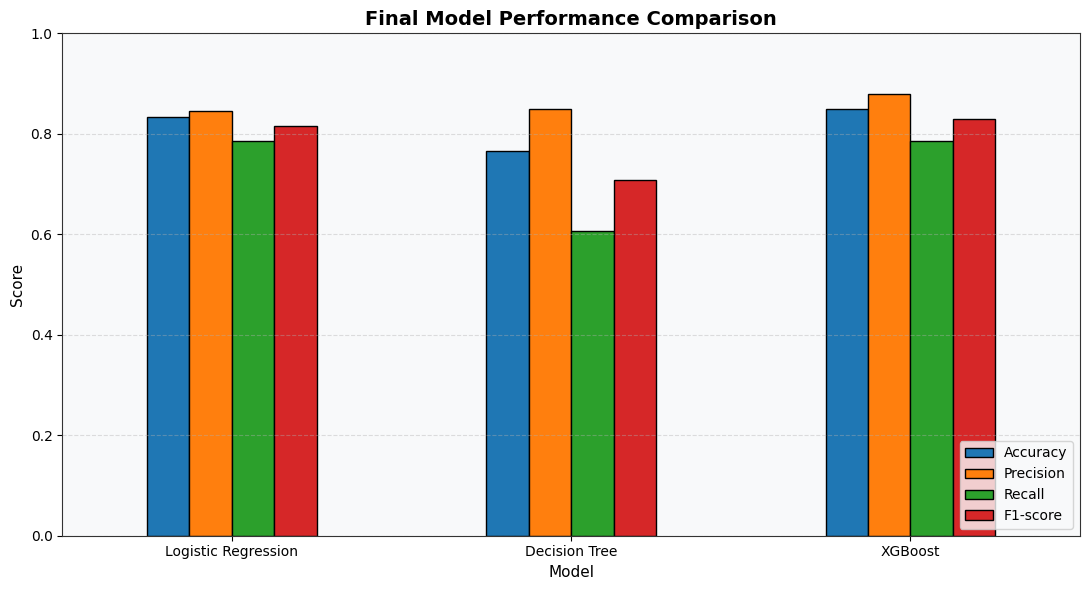

In [76]:
final_model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(11, 6),
    edgecolor="black"
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Step 11 — Save the Best Model

#### Step 11.1: Import Required Libraries

In [77]:
# Step 11: Save the Best Model

import joblib
from pathlib import Path

#### Step 11.2: Create Model Folder Path

In [78]:
models_path = project_root / "models"
models_path.mkdir(exist_ok=True)

#### Step 11.3: Save XGBoost Model

In [79]:
model_file_path = models_path / "xgboost_heart_disease_model.pkl"

joblib.dump(xgb_model, model_file_path)

print("Model saved successfully at:", model_file_path)

Model saved successfully at: d:\Projects\heart-disease-risk-prediction\models\xgboost_heart_disease_model.pkl


#### Step 11.4: Save Feature Names

In [80]:
feature_names_path = models_path / "feature_names.pkl"

joblib.dump(list(X.columns), feature_names_path)

print("Feature names saved successfully at:", feature_names_path)

Feature names saved successfully at: d:\Projects\heart-disease-risk-prediction\models\feature_names.pkl


#### Step 11.5: Test Loading the Saved Model

In [95]:
loaded_model = joblib.load(model_file_path)

test_prediction = loaded_model.predict(X_test.head(1))

print("Test prediction from loaded model:", test_prediction)

Test prediction from loaded model: [0]


# Step 12: Create Prediction Function and Test One Patient

This step prepares the logic that we will later use in the Streamlit app. It also helps you explain the project professionally in an interview. This connects with your ML course concepts like classification, model prediction, model evaluation, and deployment preparation.

#### Step 12.1: Load Saved Model and Feature Names

In [97]:
import joblib
import pandas as pd

# Load saved XGBoost model
model_file_path = project_root / "models" / "xgboost_heart_disease_model.pkl"
feature_names_path = project_root / "models" / "feature_names.pkl"

loaded_model = joblib.load(model_file_path)
feature_names = joblib.load(feature_names_path)

print("Model loaded successfully")
print("Feature names loaded successfully")
print(feature_names)

Model loaded successfully
Feature names loaded successfully
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


#### Step 12.2: Create Prediction Function

In [98]:
def predict_heart_disease_risk(patient_data):
    """
    Predict heart disease risk for one patient.

    patient_data should be a dictionary with the same feature names
    used during model training.
    """

    # Convert patient dictionary into dataframe
    patient_df = pd.DataFrame([patient_data])

    # Check missing features
    missing_features = [feature for feature in feature_names if feature not in patient_df.columns]

    if missing_features:
        raise ValueError(f"Missing features: {missing_features}")

    # Keep only required features and correct order
    patient_df = patient_df[feature_names]

    # Make prediction
    prediction = loaded_model.predict(patient_df)[0]

    # Get probability of heart disease class
    probability = loaded_model.predict_proba(patient_df)[0][1]

    # Convert prediction into readable label
    if prediction == 1:
        prediction_label = "Heart Disease Risk"
    else:
        prediction_label = "Low Heart Disease Risk"

    result = {
        "Prediction Class": int(prediction),
        "Prediction Label": prediction_label,
        "Heart Disease Probability": round(probability, 4),
        "Heart Disease Probability (%)": f"{probability * 100:.2f}%"
    }

    return result

#### Step 12.3: Test Function Using One Patient from Test Data

In [99]:
# Select one patient from test data
sample_patient = X_test.iloc[0].to_dict()

# Actual value for this patient
actual_value = y_test.iloc[0]

# Predict using saved model
prediction_result = predict_heart_disease_risk(sample_patient)

print("Sample Patient Data:")
print(sample_patient)

print("\nActual Value:", actual_value)
print("Prediction Result:")
print(prediction_result)

Sample Patient Data:
{'age': 41.0, 'sex': 1.0, 'cp': 2.0, 'trestbps': 120.0, 'chol': 157.0, 'fbs': 0.0, 'restecg': 0.0, 'thalach': 182.0, 'exang': 0.0, 'oldpeak': 0.0, 'slope': 1.0, 'ca': 0.0, 'thal': 3.0}

Actual Value: 0
Prediction Result:
{'Prediction Class': 0, 'Prediction Label': 'Low Heart Disease Risk', 'Heart Disease Probability': 0.0282, 'Heart Disease Probability (%)': '2.82%'}


#### Step 12.4: Test Function Using Custom Patient Data

In [100]:
custom_patient = {
    "age": 54,
    "sex": 1,
    "cp": 4,
    "trestbps": 130,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 1,
    "oldpeak": 2.3,
    "slope": 2,
    "ca": 1,
    "thal": 7
}

custom_prediction = predict_heart_disease_risk(custom_patient)

print("Custom Patient Prediction:")
print(custom_prediction)

Custom Patient Prediction:
{'Prediction Class': 1, 'Prediction Label': 'Heart Disease Risk', 'Heart Disease Probability': 0.9732, 'Heart Disease Probability (%)': '97.32%'}


### Medical Disclaimer

This prediction function is created for educational and learning purposes only.  
It should not be used as a real medical diagnosis tool.  
A real medical decision should always be made by qualified healthcare professionals.